In [11]:
import pandas as pd
import numpy as np
np.set_printoptions(threshold=10000, linewidth=10000)
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
'''write train data to csv, with output column'''

#start with zero array to populate with NMR data
array = np.zeros((0,2201))
for i in range(1000):
    temp_df = pd.read_csv("../RMN/train/Input/CPMG_"+f"{i:03d}.csv", sep="\t")
    #correct strings
    temp_df.T2_data = temp_df.T2_data.str.replace(",",".")
    temp_df.T2_data = temp_df.T2_data.str.replace(" ","").astype(float)#/1000
    #clip at zero
    # temp_df.T2_data = temp_df.T2_data.apply(lambda v: max(0,v))
    #add row with contents of current file
    array = np.vstack((array,temp_df.T2_data))

# scaler = sklearn.preprocessing.MinMaxScaler()
# array = scaler.fit_transform(array.T).T
train_df = pd.DataFrame(array)

#adding y column to df
train_df['y'] = pd.read_csv("../RMN/train/Output/OilSat.csv", sep="\t")['Oil_Sat']

#writing to csv file
# train_df.to_csv("./data_train.csv", sep="\t", index=False)
# train_df

In [4]:
'''write test data to csv'''

#start with zero array to populate with NMR data
array = np.zeros((0,2201))
for i in range(1000):
    temp_df = pd.read_csv("../RMN/test/Input/CPMG_"+f"{i:03d}.csv", sep="\t")
    #for test, no text correction, no clipping
    temp_df.T2_data = temp_df.T2_data.apply(lambda v: max(0,v))
    array = np.vstack((array,temp_df.T2_data))
# array = scaler.fit_transform(array.T).T
test_df = pd.DataFrame(array)
# test_df.to_csv("./data_test.csv", sep="\t", index=False)
test_df

,0,1,2,3,4,5,6,7,8,9,...,2191,2192,2193,2194,2195,2196,2197,2198,2199,2200
0,0.788302,0.833668,0.777146,0.819389,0.861003,0.807070,0.821894,0.811667,0.827137,0.796143,...,0.011400,0.095998,0.042935,0.045150,0.005347,0.042562,0.011324,0.016268,0.037239,0.000000
1,0.884277,0.864711,0.746354,0.786617,0.749206,0.736673,0.753945,0.791456,0.732960,0.744620,...,0.084529,0.010721,0.048491,0.001737,0.009000,0.054540,0.000000,0.000000,0.067455,0.000000
2,0.899784,0.774386,0.864490,0.895171,0.822695,0.785098,0.814283,0.804869,0.853816,0.828943,...,0.000000,0.000000,0.000000,0.042150,0.036852,0.010074,0.000000,0.000000,0.043007,0.000000
3,0.872215,0.913709,0.742457,0.813629,0.796481,0.763009,0.777455,0.696683,0.719256,0.806203,...,0.026313,0.010141,0.026126,0.003622,0.031001,0.062767,0.000000,0.046767,0.056365,0.046251
4,0.849244,0.797369,0.818437,0.764594,0.704282,0.759954,0.744396,0.750625,0.772093,0.712152,...,0.114391,0.013762,0.039784,0.002855,0.008673,0.042258,0.037005,0.000000,0.076023,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.825135,0.906567,0.823369,0.802071,0.890256,0.875190,0.804806,0.784156,0.792596,0.789138,...,0.000000,0.043368,0.000000,0.000000,0.044434,0.000000,0.002551,0.035874,0.000000,0.000101
996,0.851421,0.871547,0.856086,0.793908,0.768383,0.724346,0.717519,0.731956,0.813253,0.761697,...,0.011083,0.004423,0.053659,0.001334,0.000000,0.022779,0.000000,0.000000,0.000000,0.142307
997,0.924303,0.849955,0.905681,0.789871,0.823404,0.858669,0.795157,0.730247,0.719397,0.791538,...,0.083239,0.000000,0.010731,0.000000,0.000000,0.093162,0.072633,0.008447,0.039745,0.000000
998,0.871070,0.831418,0.888724,0.844934,0.819290,0.826558,0.804389,0.707092,0.745585,0.763603,...,0.072051,0.014275,0.035158,0.068349,0.123871,0.000000,0.036660,0.000000,0.000000,0.000000


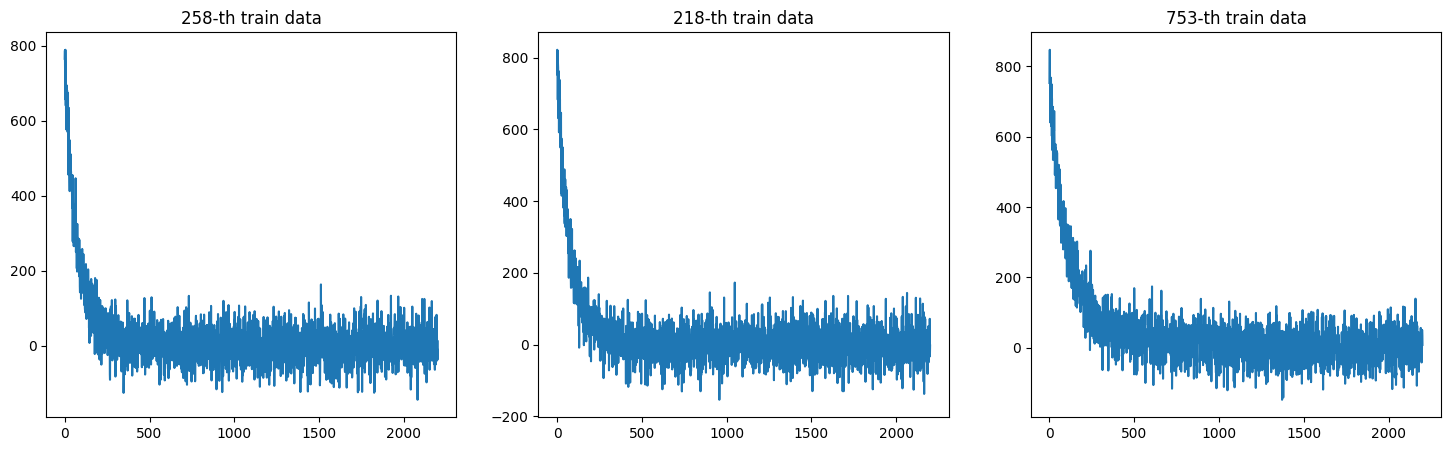

In [9]:
# '''Plot graph of test and train after clip and normalization for comparison'''
fig, ax = plt.subplots(1,3, figsize=(18,5))
for i in range(3):
    j = np.random.randint(1,1000)
    ax[i].plot(train_df.loc[j].values[:-1])
    ax[i].set_title(f"{j}-th train data")
plt.show();

# fig, ax = plt.subplots(1,5, figsize=(20,3))
# for i in range(5):
#     j = np.random.randint(1,1000)
#     ax[i].plot(test_df.loc[j].values[:-1])
#     ax[i].set_title(f"{j}-th test data")
# plt.show();

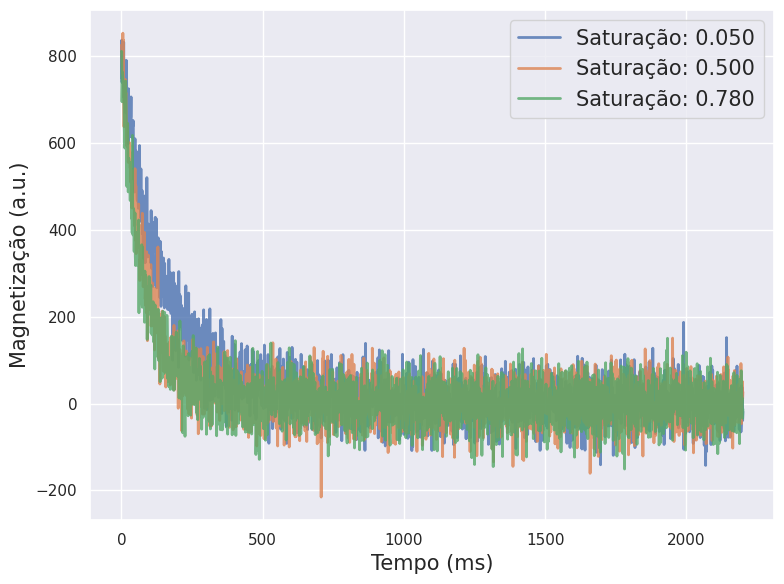

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Assumindo que 'train_df' já está carregado no seu ambiente.

# --- 1. Define o estilo ---
sns.set_theme(style="darkgrid", palette="deep")

# --- 2. Criação da figura (APENAS UM gráfico) ---
# Alterado de (1, 3) para (1, 1) e ajustado o tamanho (figsize)
fig, ax = plt.subplots(1, 1, figsize=(8, 6)) # Agora 'ax' é um único eixo

# --- 3. Seleção de índices ---
try:
    # replace=False garante que não pegaremos o mesmo índice 3x
    indices_aleatorios = np.random.choice(train_df.index, 3, replace=False)
except ValueError as e:
    print(f"Erro: {e}. Verifique se train_df tem pelo menos 3 linhas.")
    indices_aleatorios = train_df.index[:3]


# --- 4. Loop para plotar (tudo no mesmo 'ax') ---
# Não precisamos mais do 'i' (enumerate)
for j in indices_aleatorios: 
    
    # Pega os dados da amostra
    amostra_features = train_df.loc[j].values[:-1]
    saturacao_oleo = train_df.loc[j, 'y'] # Pegando o valor de 'y'

    # Plotamos tudo no mesmo 'ax'
    # Adicionamos o parâmetro 'label' para criar a legenda
    ax.plot(amostra_features, 
            linewidth=2.0,  # Linha um pouco mais fina, pois são 3
            alpha=0.8,      # Leve transparência
            # marker='o',       
            markersize=5,     # Marcador um pouco maior
            linestyle='-',
            # O label de cada linha mostrará o índice e a saturação
            label=f"Saturação: {saturacao_oleo:.3f}") 

# --- 5. Títulos, Labels e Legenda (FORA do loop) ---

# # Título geral para o gráfico
# ax.set_title(f"Comparação de 3 Amostras Aleatórias", 
#              fontsize=18, fontweight='bold')

# Labels dos eixos (só precisamos definir uma vez)
ax.set_xlabel("Tempo (ms)", fontsize=15)
ax.set_ylabel("Magnetização (a.u.)", fontsize=15)

# Adiciona a legenda para identificar qual linha é qual
# 'loc="best"' tenta posicionar a legenda no melhor lugar
ax.legend( fontsize=15, loc='best')

# --- 6. Ajuste final e exibição ---
plt.tight_layout() # Ajusta o layout
plt.show()

In [6]:
import pywt
def DWTdenoise(noisy, wvlet='db4', level=4, mode='soft'):
    # DWT decomposition
    coeffs = pywt.wavedec(noisy, wvlet, level=level)#, mode='smooth')
    cA, cD = coeffs[0], coeffs[1:]

    # Estimate noise level (MAD)
    sigma = np.median(np.abs(cD[-1])) / 0.6745 *2
    T = sigma * np.sqrt(2 * np.log(len(noisy)))

    # Thresholding
    coeffs_thresh = [cA] + [pywt.threshold(cd, T, mode=mode) for cd in cD]

    # Return denoised signal
    return pywt.waverec(coeffs_thresh, wvlet), coeffs_thresh

In [9]:
scaler = sklearn.preprocessing.MinMaxScaler()
window_length, polyorder = 271, 3


array = np.array(train_df.drop('y',axis=1))
DWT_array = np.zeros((0,2202))
for i in range(len(train_df)):
    row,_ = DWTdenoise(array[i], 'db6', level=6)
    DWT_array = np.vstack((DWT_array,row))
DWT_array = scaler.fit_transform(DWT_array.T).T
train_DWT_df = pd.DataFrame(DWT_array)
train_DWT_df['y'] = train_df['y'].copy()
# train_DWT_df.to_csv("./data_train_DWT_n.csv", sep="\t", index=False)

array = np.array(test_df)
DWT_array = np.zeros((0,2202))
for i in range(len(test_df)):
    row,_ = DWTdenoise(array[i], 'db6', level=6)
    DWT_array = np.vstack((DWT_array,row))
DWT_array = scaler.fit_transform(DWT_array.T).T
test_DWT_df = pd.DataFrame(DWT_array)

train_DWT_df.shape, test_DWT_df.shape

((1000, 2203), (1000, 2202))

In [19]:
read_train_df.shape, read_test_df.shape

((1000, 701), (1000, 700))

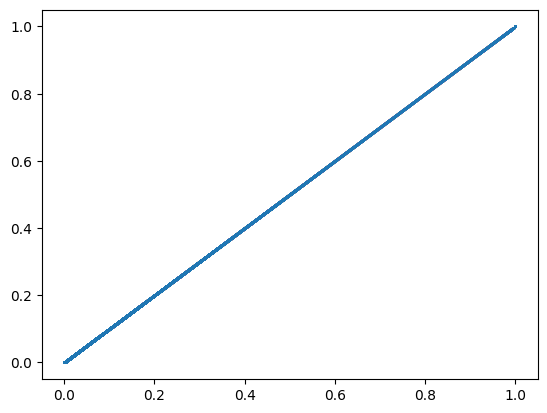

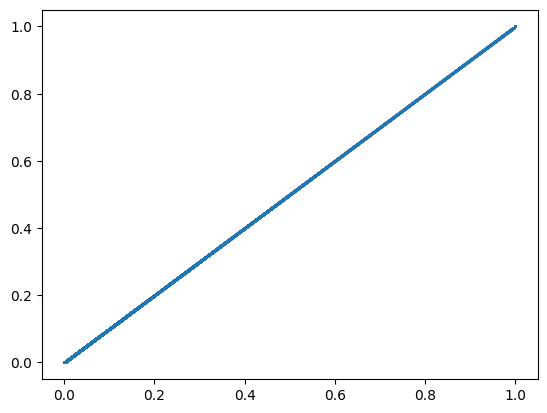

In [21]:
read_train_df = pd.read_csv('data_train_post_n_smoothing.csv', sep='\t')
read_test_df = pd.read_csv('data_test_post_n_smoothing.csv', sep='\t')
plt.scatter(read_train_df.iloc[:,:700], train_DWT_df.iloc[:,:700], s=.01)
plt.show()
plt.scatter(read_test_df.iloc[:,:700], test_DWT_df.iloc[:,:700], s=.01)
plt.show()

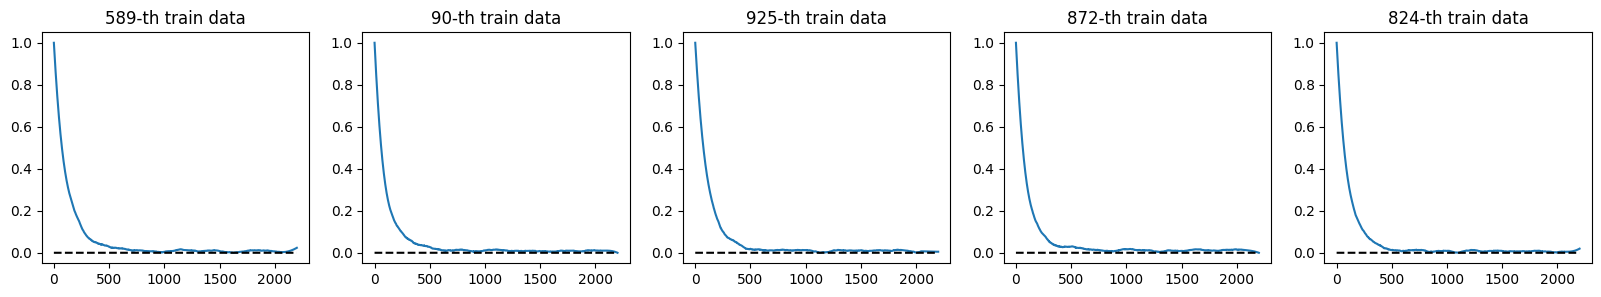

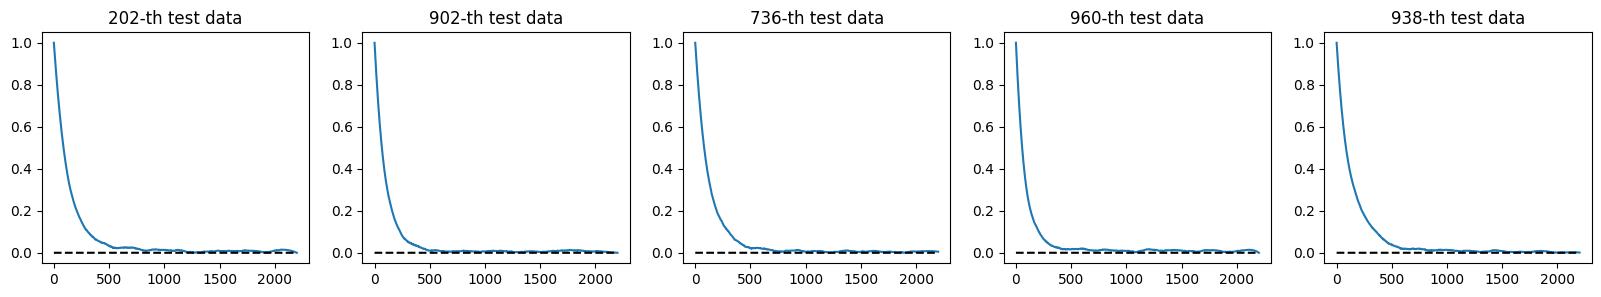

In [11]:
fig, ax = plt.subplots(1,5, figsize=(20,3))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(train_savgol_df.loc[j].values)
    ax[i].set_title(f"{j}-th train data")
    ax[i].plot([0]*train_savgol_df.shape[1],'k--')
plt.show();

fig, ax = plt.subplots(1,5, figsize=(20,3))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(test_savgol_df .loc[j].values)
    ax[i].set_title(f"{j}-th test data")
    ax[i].plot([0]*test_savgol_df.shape[1],'k--')
plt.show();

Salvando um arquivo com os primeiros 700 pontos de cada curva:

In [12]:
train_savgol_df = train_savgol_df.iloc[:,:700]
train_savgol_df['y'] = train_df['y']
# train_savgol_df.to_csv('data_train_post_n_smoothing.csv', sep='\t', index=False)

test_savgol_df  = test_savgol_df.iloc[:,:700]
# test_savgol_df.to_csv('data_test_post_n_smoothing.csv', sep='\t', index=False)